In [1]:
from IPython.display import display, HTML
import s3fit
display(HTML("<style>.container { width:100% !important; }</style>"))
import os
os.environ["OPENBLAS_NUM_THREADS"] = "64"

from copy import deepcopy as copy
import matplotlib.pyplot as plt

import warnings

import astropy.units as u
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import pathlib
import matplotlib as mpl
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from collections import defaultdict
import re
import scipy
from astropy.io import fits as asfits
from s3fit import FitFrame

mpl.rcParams['font.family'] = 'serif'


import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

s3fit_results_path = pathlib.Path('./s3fit_results/')
s3fit_results_path.mkdir(parents=True, exist_ok=True)

figs_path=pathlib.Path('./figs_spectrum_fits/')
figs_path.mkdir(parents=True, exist_ok=True)

DJAv4Catalog.to_dataframe()

467


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_slitloss_correction,grating_within_coverage,lines_fit,s3fit_result_path,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}


In [ ]:
left_wavelength=1100*u.AA
right_wavelength=3000*u.AA


for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator(3000):
    if catalog['sample_flag'] is not True:
        continue

    if catalog['determined_redshift'] < 4.5:
        continue


    grade = FL.Load_Spectrum_Grade(catalog['prism_filepath'], pd.read_csv('./DJAv4.2Catalog.csv'))
    prism_filepath = catalog.get('prism_filepath', None)
    redshift = catalog['prism_redshift']



    grating_spectrum_fits=asfits.open(pathlib.Path(prism_filepath).expanduser())

    observed_wave=grating_spectrum_fits[1].data['WAVE']*u.micron
    observed_flux=grating_spectrum_fits[1].data['FLUX']*u.Jy
    observed_flux_error=grating_spectrum_fits[1].data['ERR']*u.Jy

    non_nan_mask = np.isfinite(observed_flux.value) & np.isfinite(observed_flux_error.value)


    target_flux_lambda_unit = u.erg / u.s / u.cm**2 / u.AA

    converted_flux = observed_flux.to(target_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))
    converted_flux_error = observed_flux_error.to(target_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))

    converted_wave = observed_wave.to(u.AA)

    # error_threshold = 5*np.nanmedian(converted_flux_error.value) * u.erg / u.s / u.cm**2 / u.AA
    # non_nan_mask &= (converted_flux_error < error_threshold)

    wavelength_range_mask = (converted_wave >= left_wavelength*(1+catalog['determined_redshift'])) & (converted_wave <= right_wavelength*(1+catalog['determined_redshift']))
    non_nan_mask &= wavelength_range_mask

    wavelength_selection=np.array([[1268,1284],[1309,1316],[1342,1371],[1407,1515],[1562,1583],[1677,1740],[1760,1833],[1866,1890],[1930,1950],[2400,2580]])
    wavelength_selection=np.array([[1407,2580]])
    wave_mask = np.zeros_like(converted_wave.value, dtype=bool)
    for wave_range in wavelength_selection:
        wave_mask |= (converted_wave >= wave_range[0]*u.AA*(1+redshift)) & (converted_wave <= wave_range[1]*u.AA*(1+redshift))

    non_nan_mask &= wave_mask

    spec_valid_range = []
    if non_nan_mask.any():
        mask_int = non_nan_mask.astype(int)
        padded_mask = np.concatenate(([0], mask_int, [0]))
        diff = np.diff(padded_mask)

        starts_indices = np.where(diff == 1)[0]
        ends_indices = np.where(diff == -1)[0] - 1

        for start_idx, end_idx in zip(starts_indices, ends_indices):
            start_wave = converted_wave[start_idx].value
            end_wave = converted_wave[end_idx].value
            spec_valid_range.append([start_wave, end_wave])

    # resolution_fits=asfits.open(pathlib.Path('~/jwst_disperser_resolution').expanduser()/('jwst_nirspec_'+disperser_name+'_disp.fits'))
    # R_array=resolution_fits[1].data['R']
    # R_wave=(resolution_fits[1].data['WAVELENGTH']*u.micron).to(u.AA).value

    # k,b=np.polyfit(R_wave, R_array, 1)

    # spec_R_array=k*converted_wave.value+b


    fig, ax=plt.subplots(figsize=(35,14))
    ax.plot(converted_wave.value, converted_flux.value, color='blue', lw=1, label='Observed Spectrum')
    ax.fill_between(converted_wave.value, converted_flux.value - 1.0*converted_flux_error.value,
                    converted_flux.value + 1.0*converted_flux_error.value, color='gray', alpha=0.5, label='1$\sigma$ Error Region')
    ax.fill_between(converted_wave.value, converted_flux.value - 3.0*converted_flux_error.value,
                    converted_flux.value + 3.0*converted_flux_error.value, color='gray', alpha=0.25, label='3$\sigma$ Error Region')

    y_range_threshold = (np.nanmin(converted_flux.value[wavelength_range_mask]), np.nanmax(converted_flux.value[wavelength_range_mask]))
    ax.set_ylim(-0.2*y_range_threshold[1], 1.0*y_range_threshold[1])
    ax.set_xlim((left_wavelength*(1+redshift)).value, (right_wavelength*(1+redshift)).value)
    ax.vlines(x=1215.67*(1+redshift), ymin=-0.2*y_range_threshold[1], ymax=1.0*y_range_threshold[1], color='red', linestyle='--', lw=2, label='Lyα (1215.67 Å)')



    ax.minorticks_on()
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['top'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    ax.spines['bottom'].set_color('black')
    ax.spines['top'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['right'].set_color('black')


    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
    ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
    ax.xaxis.set_tick_params(length=6, which='major')
    ax.xaxis.set_tick_params(length=3, which='minor')
    ax.yaxis.set_tick_params(length=6, which='major')
    ax.yaxis.set_tick_params(length=3, which='minor')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1000))
    # ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=1)
    # ax.grid(visible=True, which='minor', color='lightgray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('Observed Wavelength (Å)', fontsize=24)
    ax.set_ylabel(r'$F_\lambda$ ($\rm{erg\ s^{-1}\ cm^{-2}\ \AA^{-1}}$)', fontsize=24)
    #add another x axis on the top to show rest-frame wavelength
    ax_top = ax.secondary_xaxis('top', functions=(lambda x: x / (1 + redshift), lambda x: x * (1 + redshift)))
    ax_top.minorticks_on()
    ax_top.set_xlabel('Rest-frame Wavelength (Å)', fontsize=24)
    ax_top.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
    ax_top.xaxis.set_tick_params(length=6, which='major')
    ax_top.xaxis.set_tick_params(length=3, which='minor')
    ax.legend(fontsize=20, loc='upper right')
    ax.set_title(f'Redshift: {redshift:.4f}, Grade: {grade}, Grating z: {list(catalog["grating_redshifts"].values())}', fontsize=20)


    for z in catalog['grating_redshifts'].values():
        ax.vlines(x=1215.67*(1+z), ymin=-0.2*y_range_threshold[1], ymax=1.0*y_range_threshold[1], color='green', linestyle='--', lw=2, label=f'Grating Lyα (z={z:.4f})')

    spec_valid_range = []
    if non_nan_mask.any():
        mask_int = non_nan_mask.astype(int)
        padded_mask = np.concatenate(([0], mask_int, [0]))
        diff = np.diff(padded_mask)

        starts_indices = np.where(diff == 1)[0]
        ends_indices = np.where(diff == -1)[0] - 1

        for start_idx, end_idx in zip(starts_indices, ends_indices):
            start_wave = converted_wave[start_idx].value
            end_wave = converted_wave[end_idx].value
            spec_valid_range.append([start_wave, end_wave])

    for start_wave, end_wave in spec_valid_range:
        ax.axvspan(start_wave, end_wave, color='gray', alpha=0.8)


    plt.show()


{'g235m-f170lp': {'halpha_flux': np.float64(1.2090881598293654e-17), 'halpha_flux_err': np.float64(1.41223157250523e-19), 'halpha_slitloss_correction': np.float64(1.1950264151977632), 'hbeta_flux': np.float64(3.864635824517674e-18), 'hbeta_flux_err': np.float64(1.2145182924065784e-19), 'hbeta_slitloss_correction': np.float64(1.136598237534823)}}


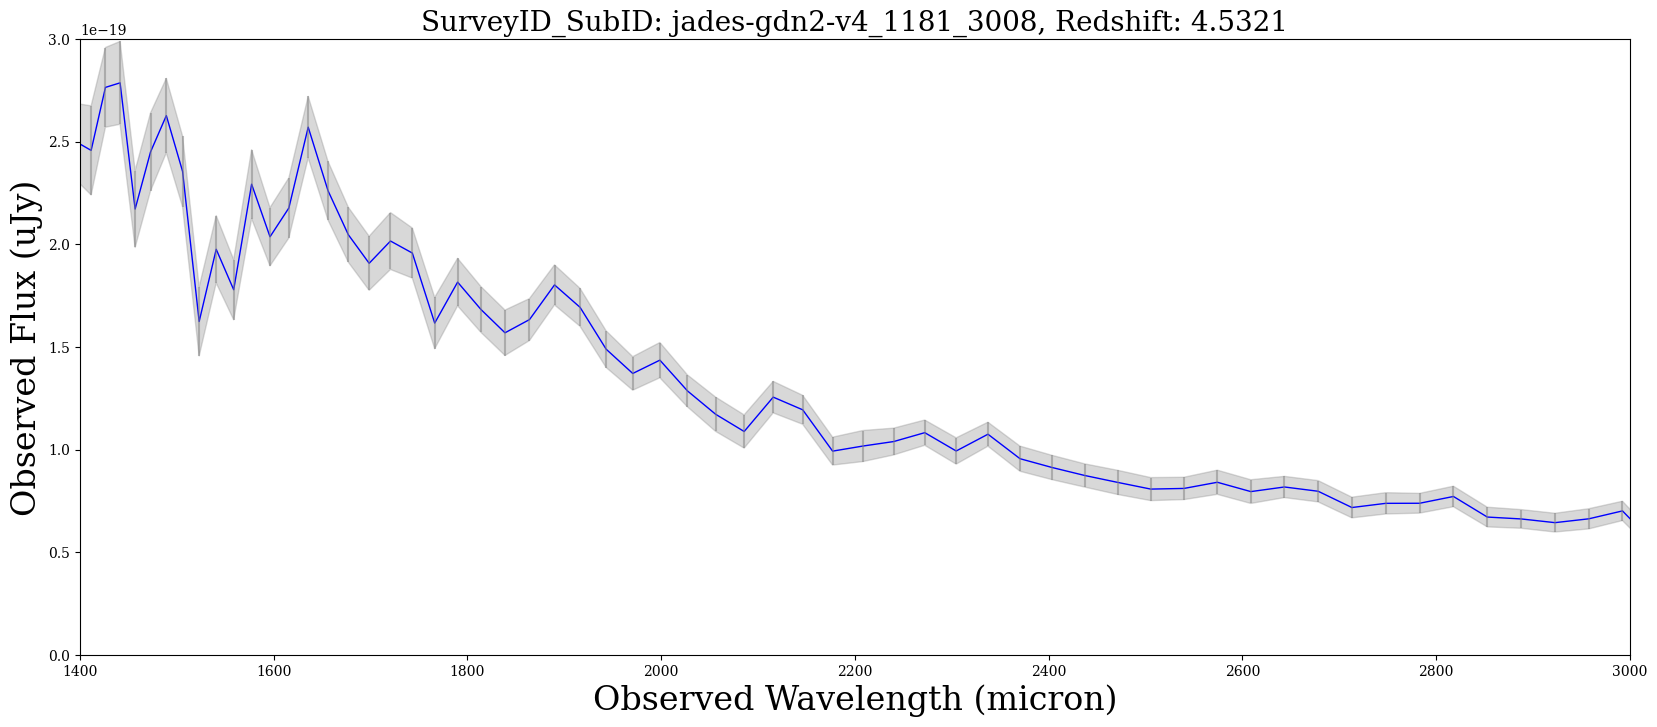

In [ ]:
for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator(1000):

    if catalog['sample_flag'] is not True:
        continue
    if catalog['determined_redshift'] < 4.5:
        continue

    print(catalog['lines_fit'])

    with asfits.open(pathlib.Path(catalog['prism_filepath']).expanduser()) as prism_spectrum_fits:
        observed_wave=prism_spectrum_fits[1].data['WAVE']*u.micron
        observed_flux_mu=prism_spectrum_fits[1].data['FLUX']*u.uJy
        observed_flux_error_mu=prism_spectrum_fits[1].data['ERR']*u.uJy

    observed_flux_lambda_unit = u.erg / u.s / u.cm**2 / u.AA
    observed_flux_lambda = observed_flux_mu.to(observed_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))
    observed_flux_error_lambda = observed_flux_error_mu.to(observed_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))

    restframe_wave = observed_wave.to(u.AA) / (1 + catalog['prism_redshift'])
    restframe_flux_lambda=observed_flux_lambda * (1 + catalog['prism_redshift'])
    restframe_flux_error_lambda=observed_flux_error_lambda * (1 + catalog['prism_redshift'])

    fig, ax=plt.subplots(figsize=(20,8))
    ax.plot(restframe_wave.value, restframe_flux_lambda.value, color='blue', lw=1, label='Observed Spectrum')
    ax.errorbar(restframe_wave.value, restframe_flux_lambda.value, yerr=restframe_flux_error_lambda.value, fmt='none', ecolor='gray', alpha=0.5, label='1$\sigma$ Error Bars')
    ax.fill_between(restframe_wave.value, restframe_flux_lambda.value - 1.0*restframe_flux_error_lambda.value,
                    restframe_flux_lambda.value + 1.0*restframe_flux_error_lambda.value, color='gray', alpha=0.3, label='1$\sigma$ Error Region')
    ax.set_xlabel('Observed Wavelength (micron)', fontsize=24)
    ax.set_ylabel('Observed Flux (uJy)', fontsize=24)
    ax.set_title(f'SurveyID_SubID: {surveyid_subid}, Redshift: {catalog["prism_redshift"]:.4f}', fontsize=20)
    ax.set_xlim(1400, 3000)
    ax.set_ylim(0,0.3e-18)
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    plt.show()


    break


In [10]:
warnings.filterwarnings('ignore', category=u.UnitsWarning)
from scipy.optimize import curve_fit

def power_law(x, amplitude, exponent):
    """
    Power law function for fitting.
    """
    return amplitude * (x ** exponent)

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():

    if not catalog['sample_flag']:
        continue
    # if catalog['determined_redshift'] < 4.5:
    #     continue

    # print(f"Processing: {surveyid_subid}")
    # print(f"Lines fit from catalog: {catalog['lines_fit']}")

    with asfits.open(pathlib.Path(catalog['prism_filepath']).expanduser()) as prism_spectrum_fits:
        observed_wave = prism_spectrum_fits[1].data['WAVE'] * u.micron
        observed_flux_mu = prism_spectrum_fits[1].data['FLUX'] * u.uJy
        observed_flux_error_mu = prism_spectrum_fits[1].data['ERR'] * u.uJy

    observed_flux_lambda_unit = u.erg / u.s / u.cm**2 / u.AA
    observed_flux_lambda = observed_flux_mu.to(observed_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))
    observed_flux_error_lambda = observed_flux_error_mu.to(observed_flux_lambda_unit, equivalencies=u.spectral_density(observed_wave))

    restframe_wave = observed_wave.to(u.AA) / (1 + catalog['prism_redshift'])
    restframe_flux_lambda = observed_flux_lambda * (1 + catalog['prism_redshift'])
    restframe_flux_error_lambda = observed_flux_error_lambda * (1 + catalog['prism_redshift'])

    fit_mask = (restframe_wave.value >= 1407) & (restframe_wave.value <= 2580)
    wave_to_fit = restframe_wave[fit_mask].value
    flux_to_fit = restframe_flux_lambda[fit_mask].value
    error_to_fit = restframe_flux_error_lambda[fit_mask].value

    if np.any(error_to_fit <= 0):
        print("Warning: Non-positive error values found. These will be ignored in the fit.")
        valid_error_mask = error_to_fit > 0
        wave_to_fit = wave_to_fit[valid_error_mask]
        flux_to_fit = flux_to_fit[valid_error_mask]
        error_to_fit = error_to_fit[valid_error_mask]

    if np.any(np.isnan(flux_to_fit)) or np.any(np.isnan(error_to_fit)):
        print("Warning: NaN values found in flux or error arrays. These will be ignored in the fit.")
        valid_nan_mask = ~np.isnan(flux_to_fit) & ~np.isnan(error_to_fit)
        wave_to_fit = wave_to_fit[valid_nan_mask]
        flux_to_fit = flux_to_fit[valid_nan_mask]
        error_to_fit = error_to_fit[valid_nan_mask]

    fit_successful = False
    if len(wave_to_fit) > 2:
        try:
            initial_guess = [np.median(flux_to_fit), -1.5]
            popt, pcov = curve_fit(
                power_law,
                xdata=wave_to_fit,
                ydata=flux_to_fit,
                p0=initial_guess,
                sigma=error_to_fit,
                absolute_sigma=True,
                maxfev=500000
            )

            fit_amplitude, fit_exponent = popt
            perr = np.sqrt(np.diag(pcov))
            fit_amplitude_err, fit_exponent_err = perr
            fit_successful = True

            # print("\n--- Power-law Fit Results ---")
            # print(f"  Amplitude: {fit_amplitude:.3e} ± {fit_amplitude_err:.3e}")
            # print(f"  Exponent:  {fit_exponent:.3f} ± {fit_exponent_err:.3f}")
            # print("---------------------------\n")
            catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters'] = {
                    'amplitude': fit_amplitude,
                    'amplitude_error': fit_amplitude_err,
                    'exponent': fit_exponent,
                    'exponent_error': fit_exponent_err
            }


        except RuntimeError as e:
            print(f"Fit failed for {surveyid_subid}: {e}")
            catalog['sample_flag']=False
            catalog['reason_for_exclusion'].append('No Valid UV fit')
        except ValueError as e:
            print(f"Fit failed for {surveyid_subid} due to value error: {e}")
            catalog['sample_flag'] = False
            catalog['reason_for_exclusion'].append('Not enough valid data points for power-law fit')
    else:
        print(f"Not enough data points in the range [1407, 2580] AA to perform a fit for {surveyid_subid}.")
        catalog['sample_flag'] = False
        catalog['reason_for_exclusion'].append('Not enough valid data points for power-law fit')

    DJAv4Catalog.update_catalog_item(surveyid_subid, catalog)

    # fig, ax = plt.subplots(figsize=(20, 8))
    # ax.plot(restframe_wave.value, restframe_flux_lambda.value, color='blue', lw=1, alpha=0.8, label='Observed Spectrum')
    # ax.fill_between(restframe_wave.value, restframe_flux_lambda.value - restframe_flux_error_lambda.value,
    #                 restframe_flux_lambda.value + restframe_flux_error_lambda.value, color='gray', alpha=0.3, label='1$\sigma$ Error Region')

    # if fit_successful:
    #     fit_line = power_law(wave_to_fit, fit_amplitude, fit_exponent)
    #     ax.plot(wave_to_fit, fit_line, color='red', lw=2.5,
    #             label=f'Power-law Fit ($\\alpha_\\lambda$ = {fit_exponent:.2f})')

    # ax.set_xlabel('Rest-frame Wavelength ($\AA$)', fontsize=24)
    # ax.set_ylabel(f'Flux ({observed_flux_lambda_unit})', fontsize=24)
    # ax.set_title(f'SurveyID_SubID: {surveyid_subid}, Redshift: {catalog["prism_redshift"]:.4f}', fontsize=20)
    # ax.set_xlim(1400, 3000)
    # ax.set_ylim(-0.1e-18, 0.5e-18)
    # ax.grid(True, linestyle='--', alpha=0.6)
    # ax.legend(fontsize=18)
    # plt.show()

DJAv4Catalog.save_catalog_to_pkl('./DJAV4.2Catalog.pkl')

Not enough data points in the range [1407, 2580] AA to perform a fit for rubies-uds22-v4_4233_139709.
Not enough data points in the range [1407, 2580] AA to perform a fit for rubies-uds22-v4_4233_125453.
Not enough data points in the range [1407, 2580] AA to perform a fit for rubies-egs52-v4_4233_37248.
Not enough data points in the range [1407, 2580] AA to perform a fit for rubies-egs52-v4_4233_946240.
Not enough data points in the range [1407, 2580] AA to perform a fit for rubies-egs52-v4_4233_37124.
Not enough data points in the range [1407, 2580] AA to perform a fit for rubies-egs51-v4_4233_15818.
Not enough data points in the range [1407, 2580] AA to perform a fit for rubies-egs51-v4_4233_22229.
Not enough data points in the range [1407, 2580] AA to perform a fit for rubies-egs61-v4_4233_60935.
Not enough data points in the range [1407, 2580] AA to perform a fit for rubies-egs63-v4_4233_960550.


In [11]:
uv_slope_list=[]
uv_slope_err_list=[]
balmer_ratio_list=[]
balmer_ratio_err_list=[]

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    best_SNR=-1
    best_Signal=None
    best_Noise=None
    best_key=None
    for key, dict_value in catalog['lines_fit'].items():

        balmer_decrement_uncertainty=FL.BalmerDecrementUncertainty(dict_value['halpha_flux'],dict_value['halpha_flux_err'],dict_value['hbeta_flux'],dict_value['hbeta_flux_err'])
        balmer_decrement=dict_value['halpha_flux']/dict_value['hbeta_flux']
        snr=abs(balmer_decrement/balmer_decrement_uncertainty)
        if snr>best_SNR:
            best_SNR=snr
            best_Signal=balmer_decrement
            best_Noise=balmer_decrement_uncertainty
            best_key=key
    if best_Signal is None:
        catalog['dust_curve_parameters']={}
        catalog['sample_flag']=False
        catalog['reason_for_exclusion'].append('No valid Balmer decrement measurement')
        DJAv4Catalog.update_catalog_item(surveyid_subid, catalog)
        continue

    balmer_ratio_list.append(best_Signal)
    balmer_ratio_err_list.append(best_Noise)
    catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']={key: catalog['lines_fit'][best_key][key] for key in catalog['lines_fit'][best_key].keys()}
    DJAv4Catalog.update_catalog_item(surveyid_subid, catalog)

    uv_slope_list.append(catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent'])
    uv_slope_err_list.append(catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent_error'])


uv_slope_array=np.array(uv_slope_list)
uv_slope_err_array=np.array(uv_slope_err_list)
balmer_ratio_array=np.array(balmer_ratio_list)
balmer_ratio_err_array=np.array(balmer_ratio_err_list)

balmer_decrement_array=np.log(balmer_ratio_array/(2.86))
balmer_decrement_uncertainty_array=balmer_ratio_err_array/balmer_ratio_array

In [15]:
DJAv4Catalog.to_dataframe()

,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_slitloss_correction,grating_within_coverage,lines_fit,s3fit_result_path,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{prism-clear, g235m-f170lp, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}


(-4.0, 0.0)

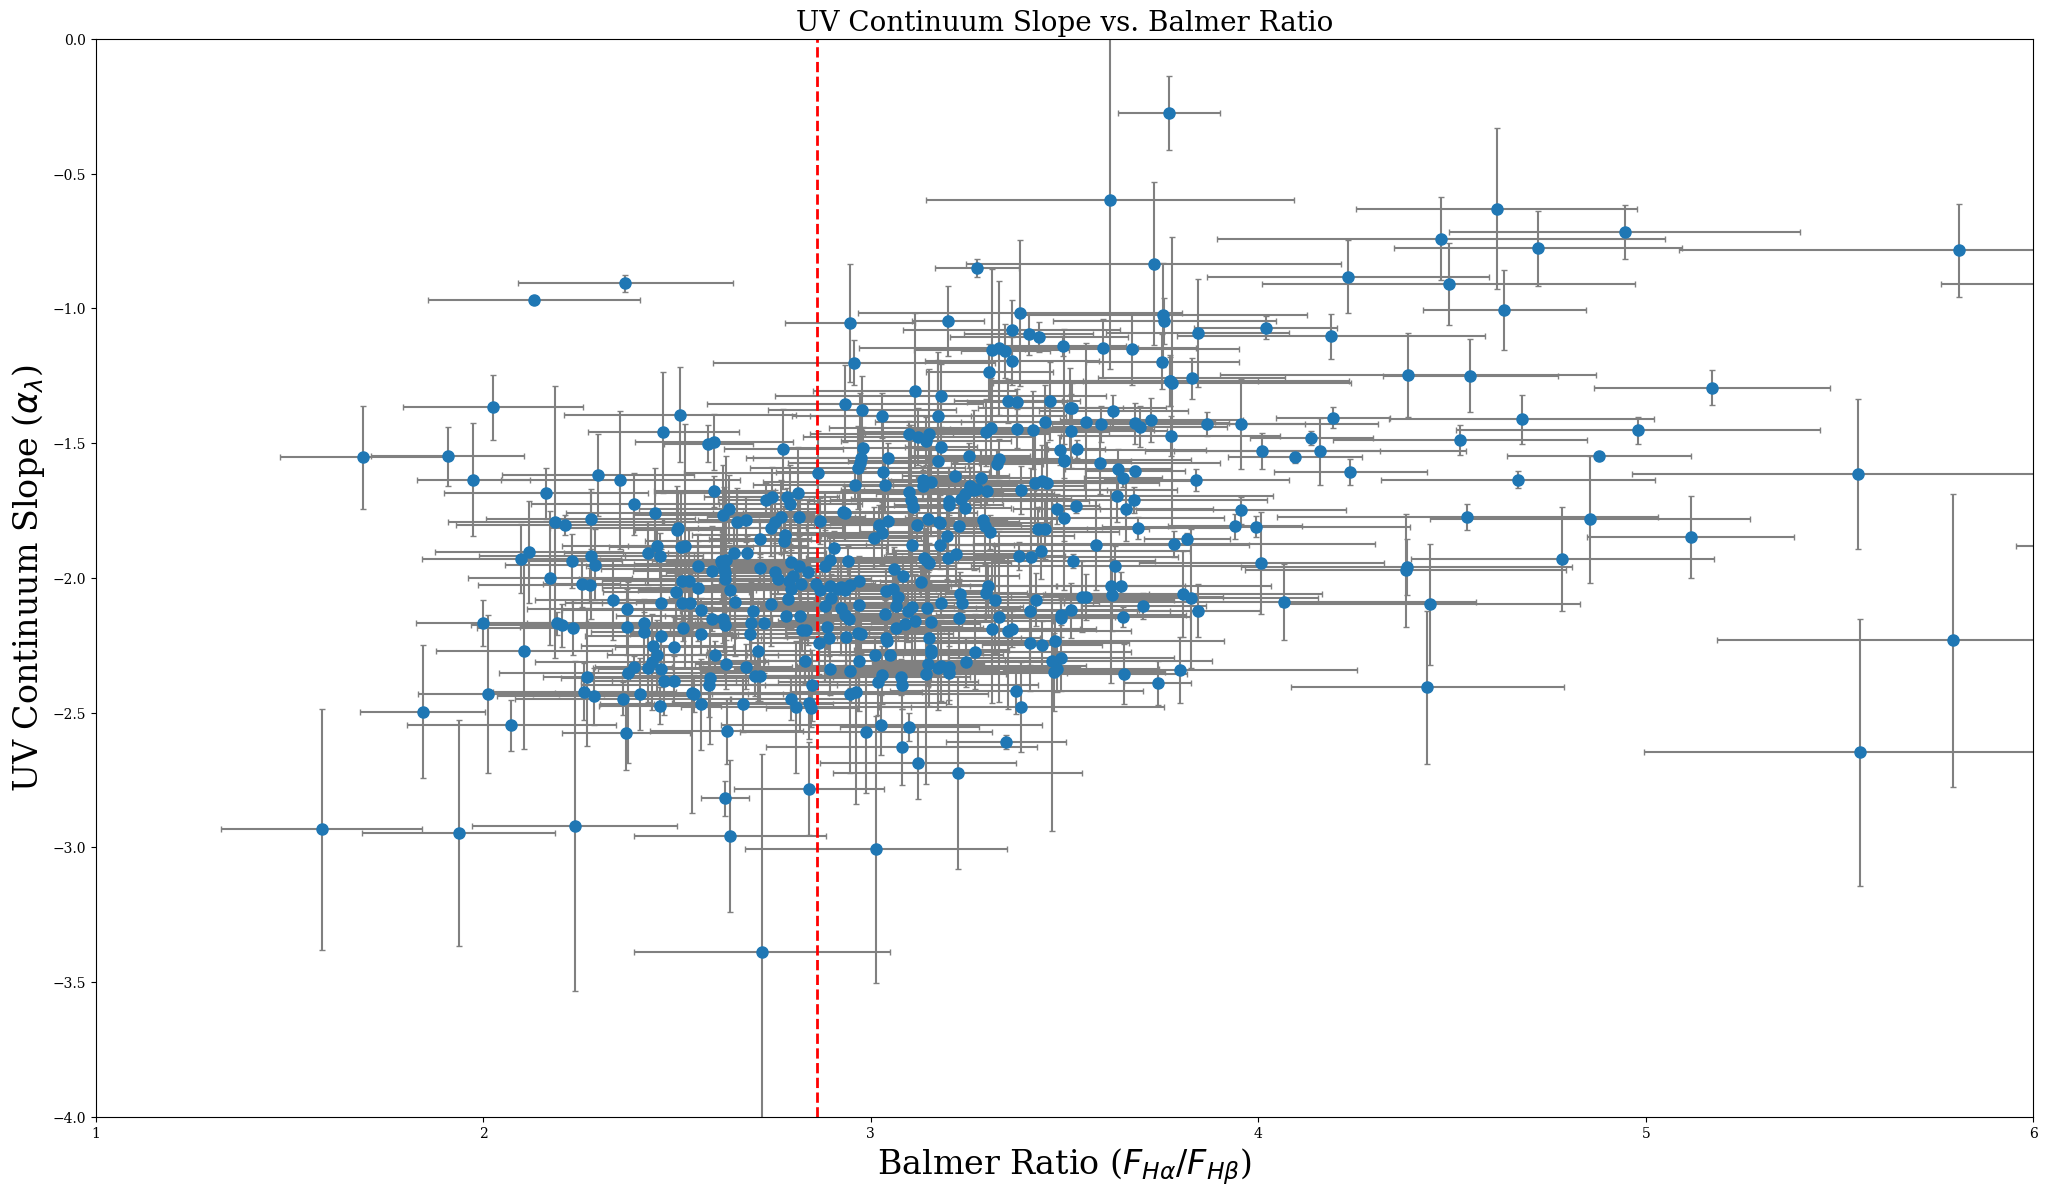

In [3]:
fig, ax = plt.subplots(figsize=(25,14))
ax.errorbar(balmer_ratio_list, uv_slope_list,
            xerr=balmer_ratio_err_list,
            yerr=uv_slope_err_list,
            fmt='o', ecolor='gray', capsize=2, markersize=8, label='Data Points')
ax.set_xlabel(r'Balmer Ratio ($F_{H\alpha}/F_{H\beta}$)', fontsize=24)
ax.set_ylabel(r'UV Continuum Slope ($\alpha_\lambda$)', fontsize=24)
ax.set_title('UV Continuum Slope vs. Balmer Ratio', fontsize=20)
ax.axvline(x=2.86, color='red', linestyle='--', lw=2, label='Case B Recombination (2.86)')
ax.set_xlim(1,6)
ax.set_ylim(-4,0)

(-3.0, -0.5)

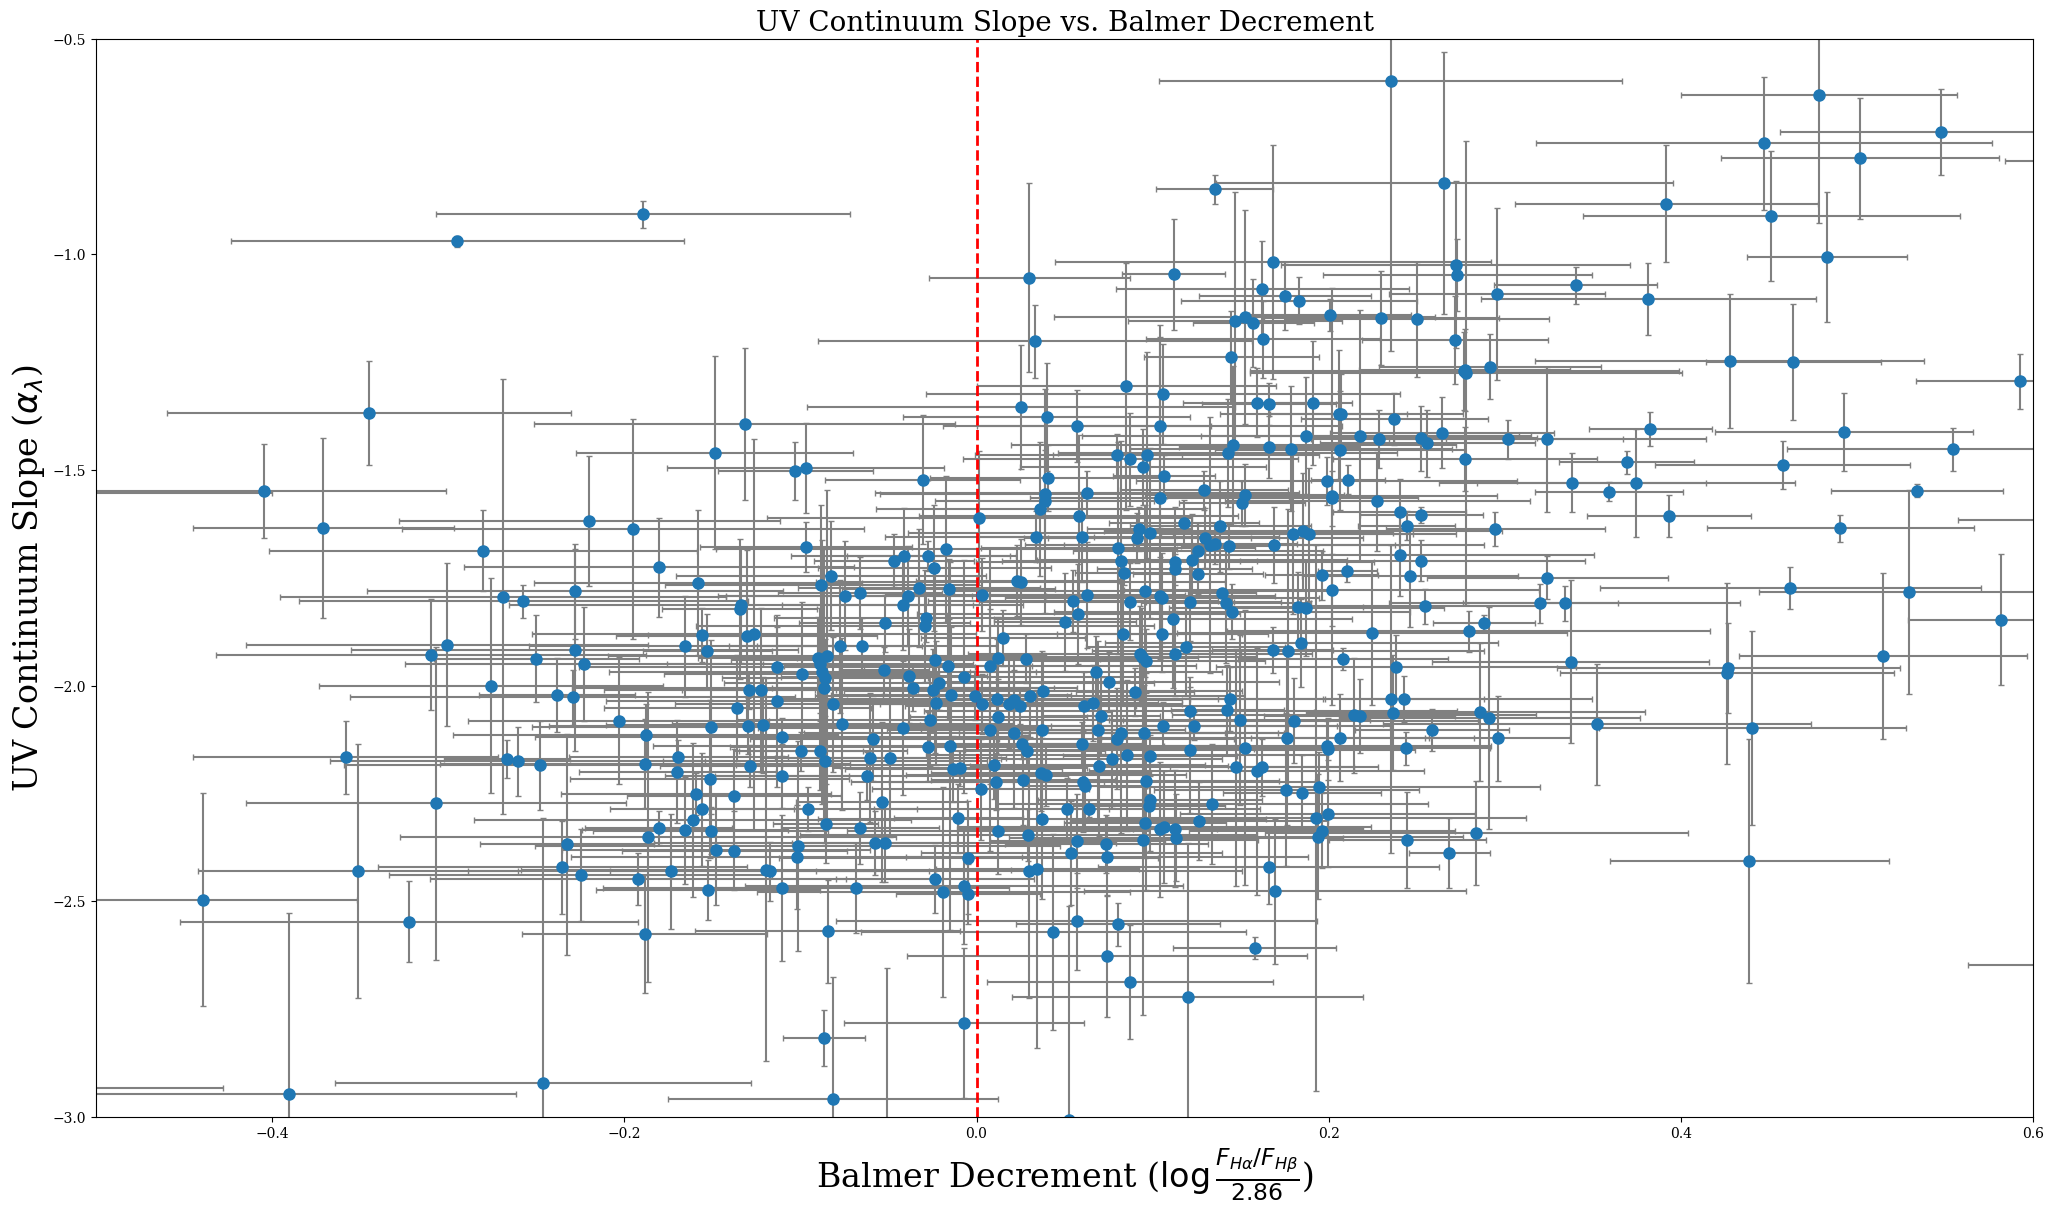

In [5]:
fig, ax = plt.subplots(figsize=(25,14))
ax.errorbar(balmer_decrement_array, uv_slope_array,
            xerr=balmer_decrement_uncertainty_array,
            yerr=uv_slope_err_array,
            fmt='o', ecolor='gray', capsize=2, markersize=8, label='Data Points')
ax.set_xlabel(r'Balmer Decrement ($\log \frac{F_{H\alpha}/F_{H\beta}}{2.86}$)', fontsize=24)
ax.set_ylabel(r'UV Continuum Slope ($\alpha_\lambda$)', fontsize=24)
ax.set_title('UV Continuum Slope vs. Balmer Decrement', fontsize=20)
ax.axvline(x=0, color='red', linestyle='--', lw=2, label='Case B Recombination (2.86)')
ax.set_xlim(-0.5,0.6)
ax.set_ylim(-3,-0.5)

Select 0.0-0.6

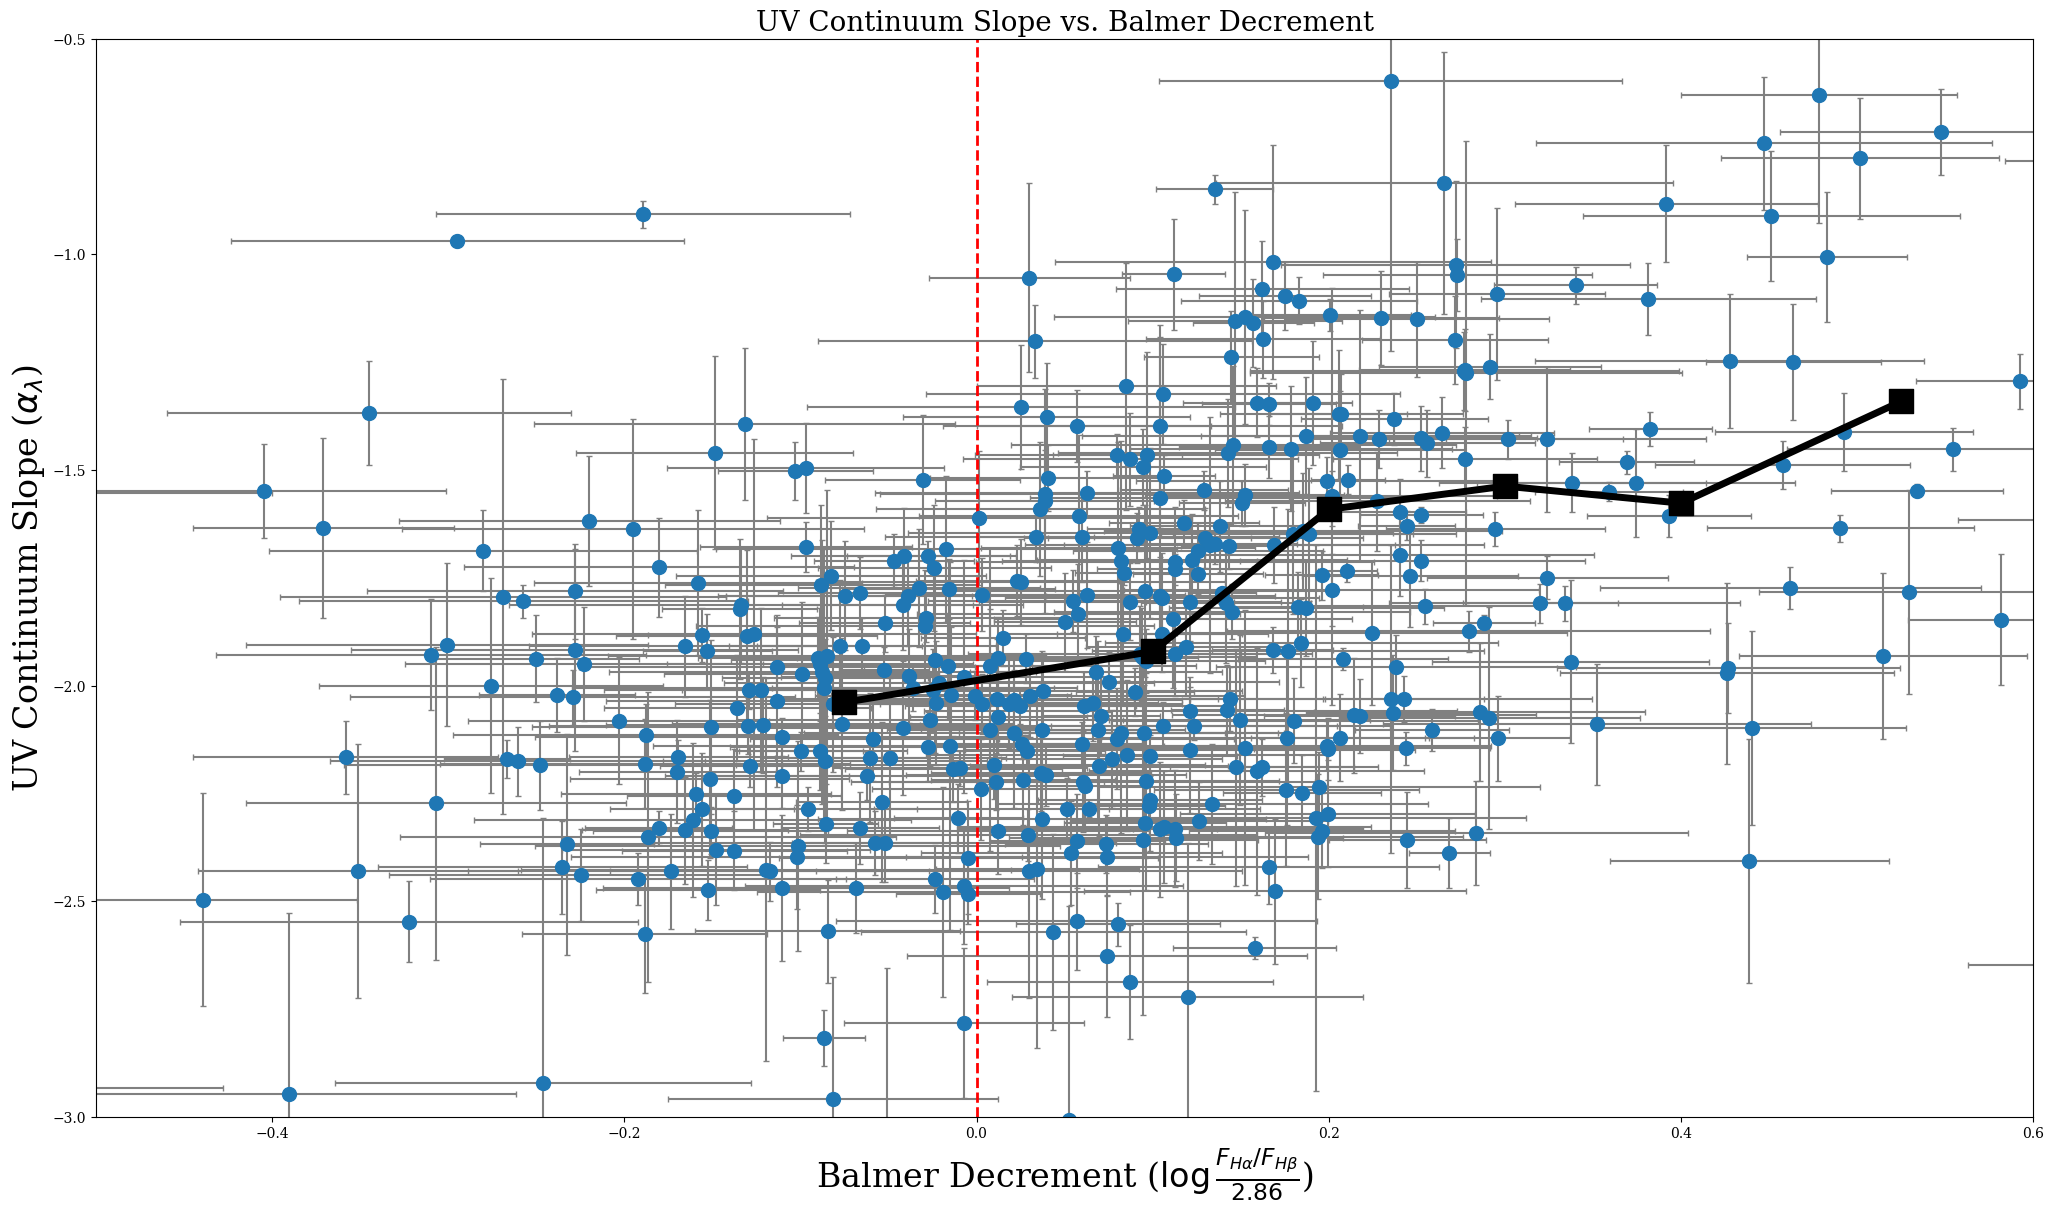

In [17]:
from matplotlib import lines
from numpy import percentile


fig, ax = plt.subplots(figsize=(25,14))
ax.errorbar(balmer_decrement_array, uv_slope_array,
            xerr=balmer_decrement_uncertainty_array,
            yerr=uv_slope_err_array,
            fmt='o', ecolor='gray', capsize=2, markersize=10, label='Data Points')
ax.set_xlabel(r'Balmer Decrement ($\log \frac{F_{H\alpha}/F_{H\beta}}{2.86}$)', fontsize=24)
ax.set_ylabel(r'UV Continuum Slope ($\alpha_\lambda$)', fontsize=24)
ax.set_title('UV Continuum Slope vs. Balmer Decrement', fontsize=20)
ax.axvline(x=0, color='red', linestyle='--', lw=2, label='Case B Recombination (2.86)')
ax.set_xlim(-0.5,0.6)
ax.set_ylim(-3,-0.5)

group_conditions = [(-0.2,0.05),(0.05,0.15), (0.15,0.25),(0.25,0.35),(0.35,0.45),(0.45,0.6)]
last_point_x=None
last_point_y=None
for lower, upper in group_conditions:
    group_mask = (balmer_decrement_array >= lower) & (balmer_decrement_array < upper)
    if np.sum(group_mask) == 0:
        continue
    group_uv_slopes = uv_slope_array[group_mask]
    group_uv_slope_errs = uv_slope_err_array[group_mask]

    lower_value=0
    upper_value=100


    mask_lower_16_upper_84 = (group_uv_slopes >= percentile(group_uv_slopes,lower_value)) & (group_uv_slopes <= percentile(group_uv_slopes, upper_value))
    group_uv_slopes = group_uv_slopes[mask_lower_16_upper_84]


    weighted_mean_uv_slope = np.average(group_uv_slopes)

    mid_point = (lower + upper) / 2
    z=30

    ax.scatter(mid_point, weighted_mean_uv_slope,
                marker='s', color='black', s=288,
                label=f'Bin [{lower:.2f}, {upper:.2f}] Mean' if lower == group_conditions[0][0] else "", zorder=z)
    if last_point_x is not None and last_point_y is not None:
        ax.plot([last_point_x, mid_point], [last_point_y, weighted_mean_uv_slope], color='black', linewidth=5, zorder=z)
    last_point_x = mid_point
    last_point_y = weighted_mean_uv_slope

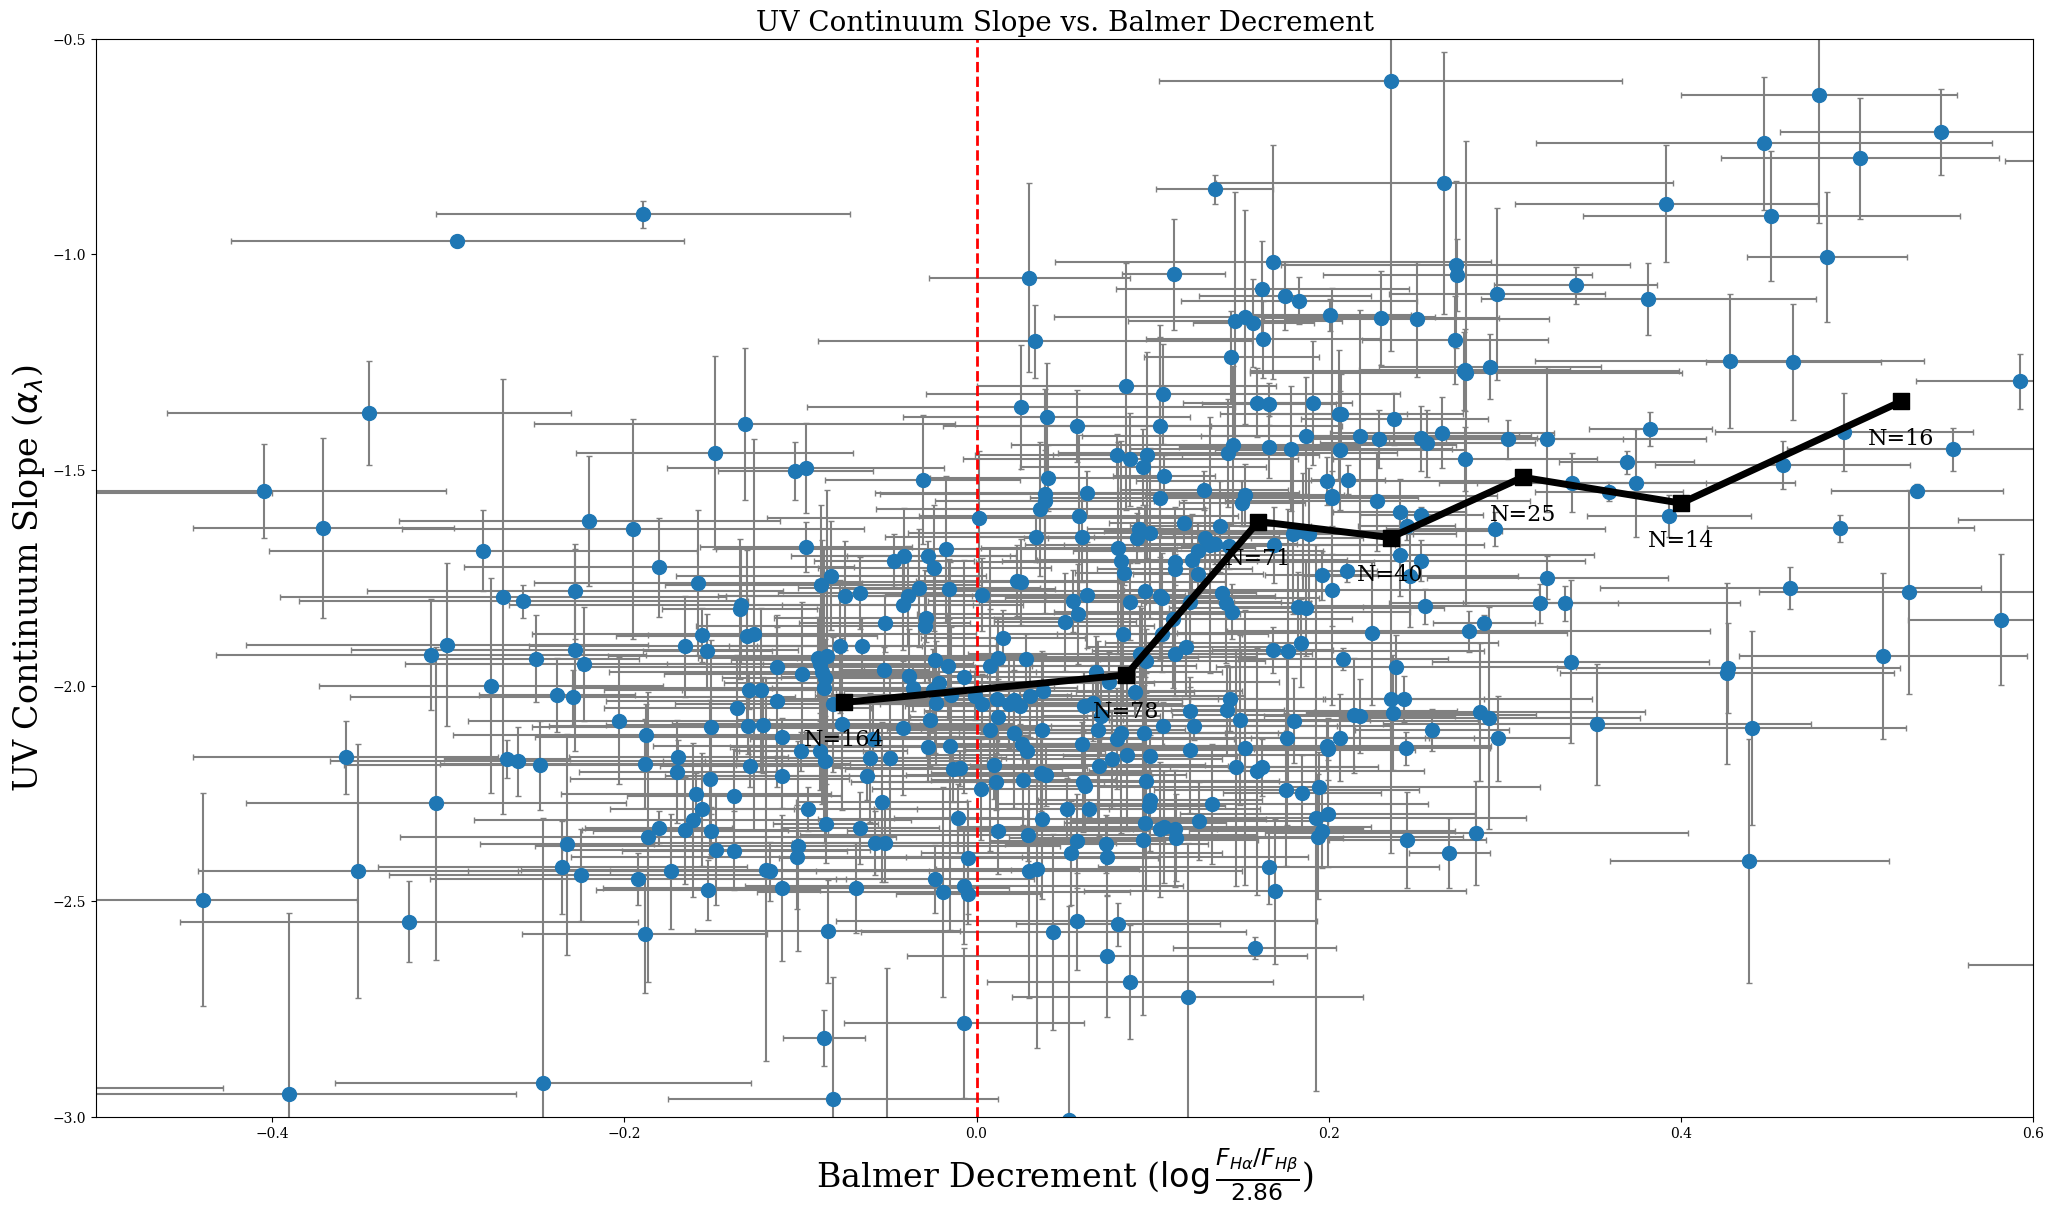

In [16]:
from numpy import percentile


fig, ax = plt.subplots(figsize=(25,14))
ax.errorbar(balmer_decrement_array, uv_slope_array,
            xerr=balmer_decrement_uncertainty_array,
            yerr=uv_slope_err_array,
            fmt='o', ecolor='gray', capsize=2, markersize=10, label='Data Points')
ax.set_xlabel(r'Balmer Decrement ($\log \frac{F_{H\alpha}/F_{H\beta}}{2.86}$)', fontsize=24)
ax.set_ylabel(r'UV Continuum Slope ($\alpha_\lambda$)', fontsize=24)
ax.set_title('UV Continuum Slope vs. Balmer Decrement', fontsize=20)
ax.axvline(x=0, color='red', linestyle='--', lw=2, label='Case B Recombination (2.86)')
ax.set_xlim(-0.5,0.6)
ax.set_ylim(-3,-0.5)

group_conditions = [(-0.2,0.05),(0.05,0.12), (0.12,0.2),(0.2,0.27),(0.27,0.35),(0.35,0.45),(0.45,0.6)]
last_point_x=None
last_point_y=None

for lower, upper in group_conditions:
    group_mask = (balmer_decrement_array >= lower) & (balmer_decrement_array < upper)
    group_num=np.sum(group_mask)
    if group_num == 0:
        continue
    group_uv_slopes = uv_slope_array[group_mask]
    group_uv_slope_errs = uv_slope_err_array[group_mask]

    lower_value=0
    upper_value=100


    mask_lower_16_upper_84 = (group_uv_slopes >= percentile(group_uv_slopes,lower_value)) & (group_uv_slopes <= percentile(group_uv_slopes, upper_value))
    group_uv_slopes = group_uv_slopes[mask_lower_16_upper_84]


    weighted_mean_uv_slope = np.average(group_uv_slopes)

    mid_point = (lower + upper) / 2
    z=30

    ax.scatter(mid_point, weighted_mean_uv_slope,
                marker='s', color='black', s=144,
                label=f'Bin [{lower:.2f}, {upper:.2f}] Mean' if lower == group_conditions[0][0] else "", zorder=z)

    if last_point_x is not None and last_point_y is not None:
        ax.plot([last_point_x, mid_point], [last_point_y, weighted_mean_uv_slope], color='black', linewidth=5, zorder=z)
    last_point_x = mid_point
    last_point_y = weighted_mean_uv_slope

    plt.text(mid_point, weighted_mean_uv_slope-0.1, f'N={group_num}', fontsize=16, ha='center',zorder=z)

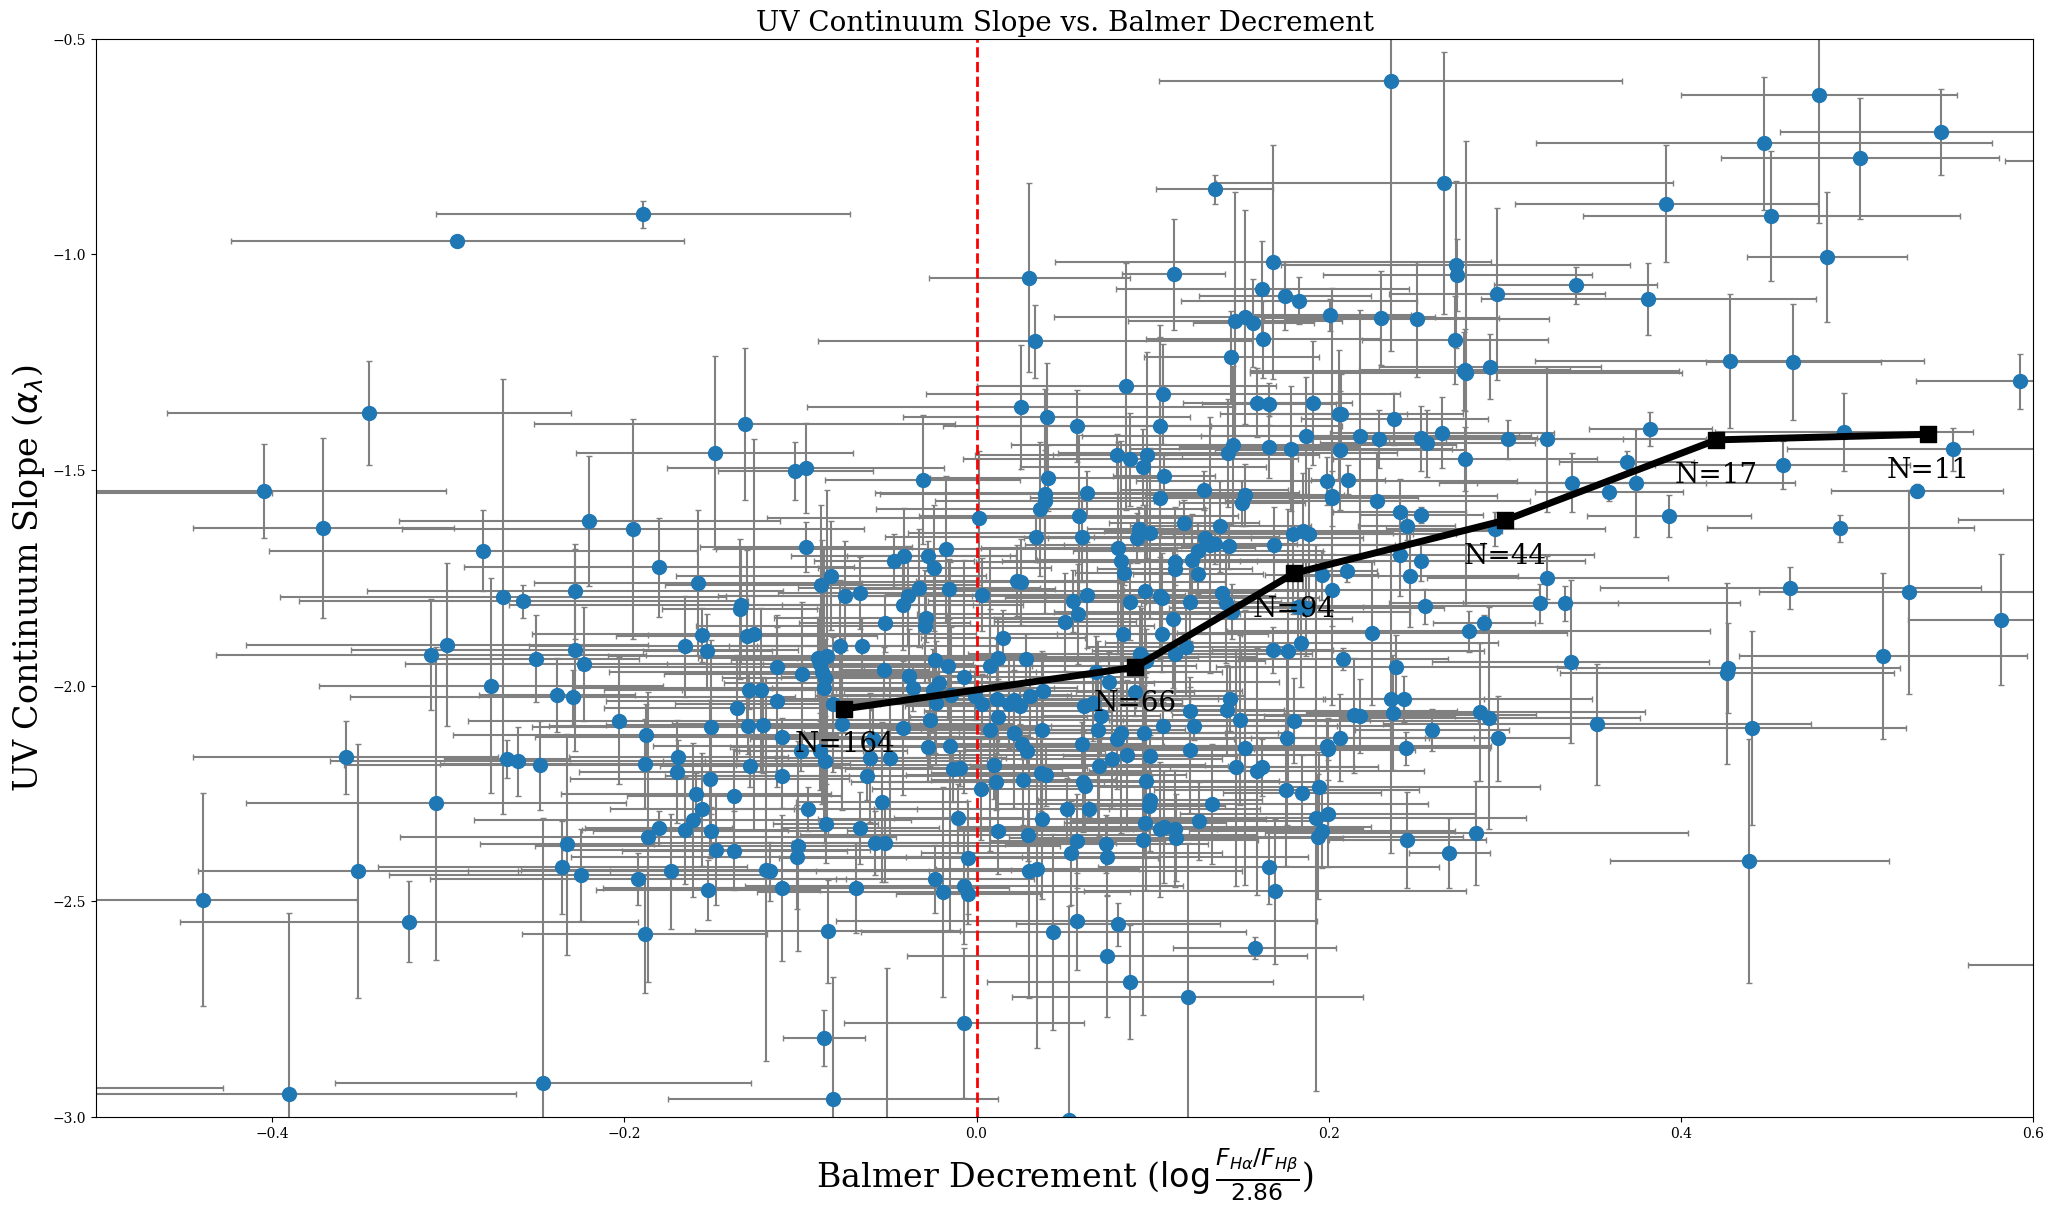

In [4]:
from numpy import percentile


fig, ax = plt.subplots(figsize=(25,14))
ax.errorbar(balmer_decrement_array, uv_slope_array,
            xerr=balmer_decrement_uncertainty_array,
            yerr=uv_slope_err_array,
            fmt='o', ecolor='gray', capsize=2, markersize=10, label='Data Points')
ax.set_xlabel(r'Balmer Decrement ($\log \frac{F_{H\alpha}/F_{H\beta}}{2.86}$)', fontsize=24)
ax.set_ylabel(r'UV Continuum Slope ($\alpha_\lambda$)', fontsize=24)
ax.set_title('UV Continuum Slope vs. Balmer Decrement', fontsize=20)
ax.axvline(x=0, color='red', linestyle='--', lw=2, label='Case B Recombination (2.86)')
ax.set_xlim(-0.5,0.6)
ax.set_ylim(-3,-0.5)

group_conditions = [(-0.2,0.05),(0.06,0.12), (0.12,0.24),(0.24,0.36),(0.36,0.48),(0.48,0.6)]
last_point_x=None
last_point_y=None

for lower, upper in group_conditions:
    group_mask = (balmer_decrement_array >= lower) & (balmer_decrement_array < upper)
    group_num=np.sum(group_mask)
    if group_num == 0:
        continue
    group_uv_slopes = uv_slope_array[group_mask]
    group_uv_slope_errs = uv_slope_err_array[group_mask]

    lower_value=5
    upper_value=100-lower_value


    mask_lower_16_upper_84 = (group_uv_slopes >= percentile(group_uv_slopes,lower_value)) & (group_uv_slopes <= percentile(group_uv_slopes, upper_value))
    group_uv_slopes = group_uv_slopes[mask_lower_16_upper_84]


    weighted_mean_uv_slope = np.average(group_uv_slopes)

    mid_point = (lower + upper) / 2
    z=30

    ax.scatter(mid_point, weighted_mean_uv_slope,
                marker='s', color='black', s=144,
                label=f'Bin [{lower:.2f}, {upper:.2f}] Mean' if lower == group_conditions[0][0] else "", zorder=z)

    if last_point_x is not None and last_point_y is not None:
        ax.plot([last_point_x, mid_point], [last_point_y, weighted_mean_uv_slope], color='black', linewidth=5, zorder=z)
    last_point_x = mid_point
    last_point_y = weighted_mean_uv_slope

    plt.text(mid_point, weighted_mean_uv_slope-0.1, f'N={group_num}', fontsize=20, ha='center',zorder=z,c='black')

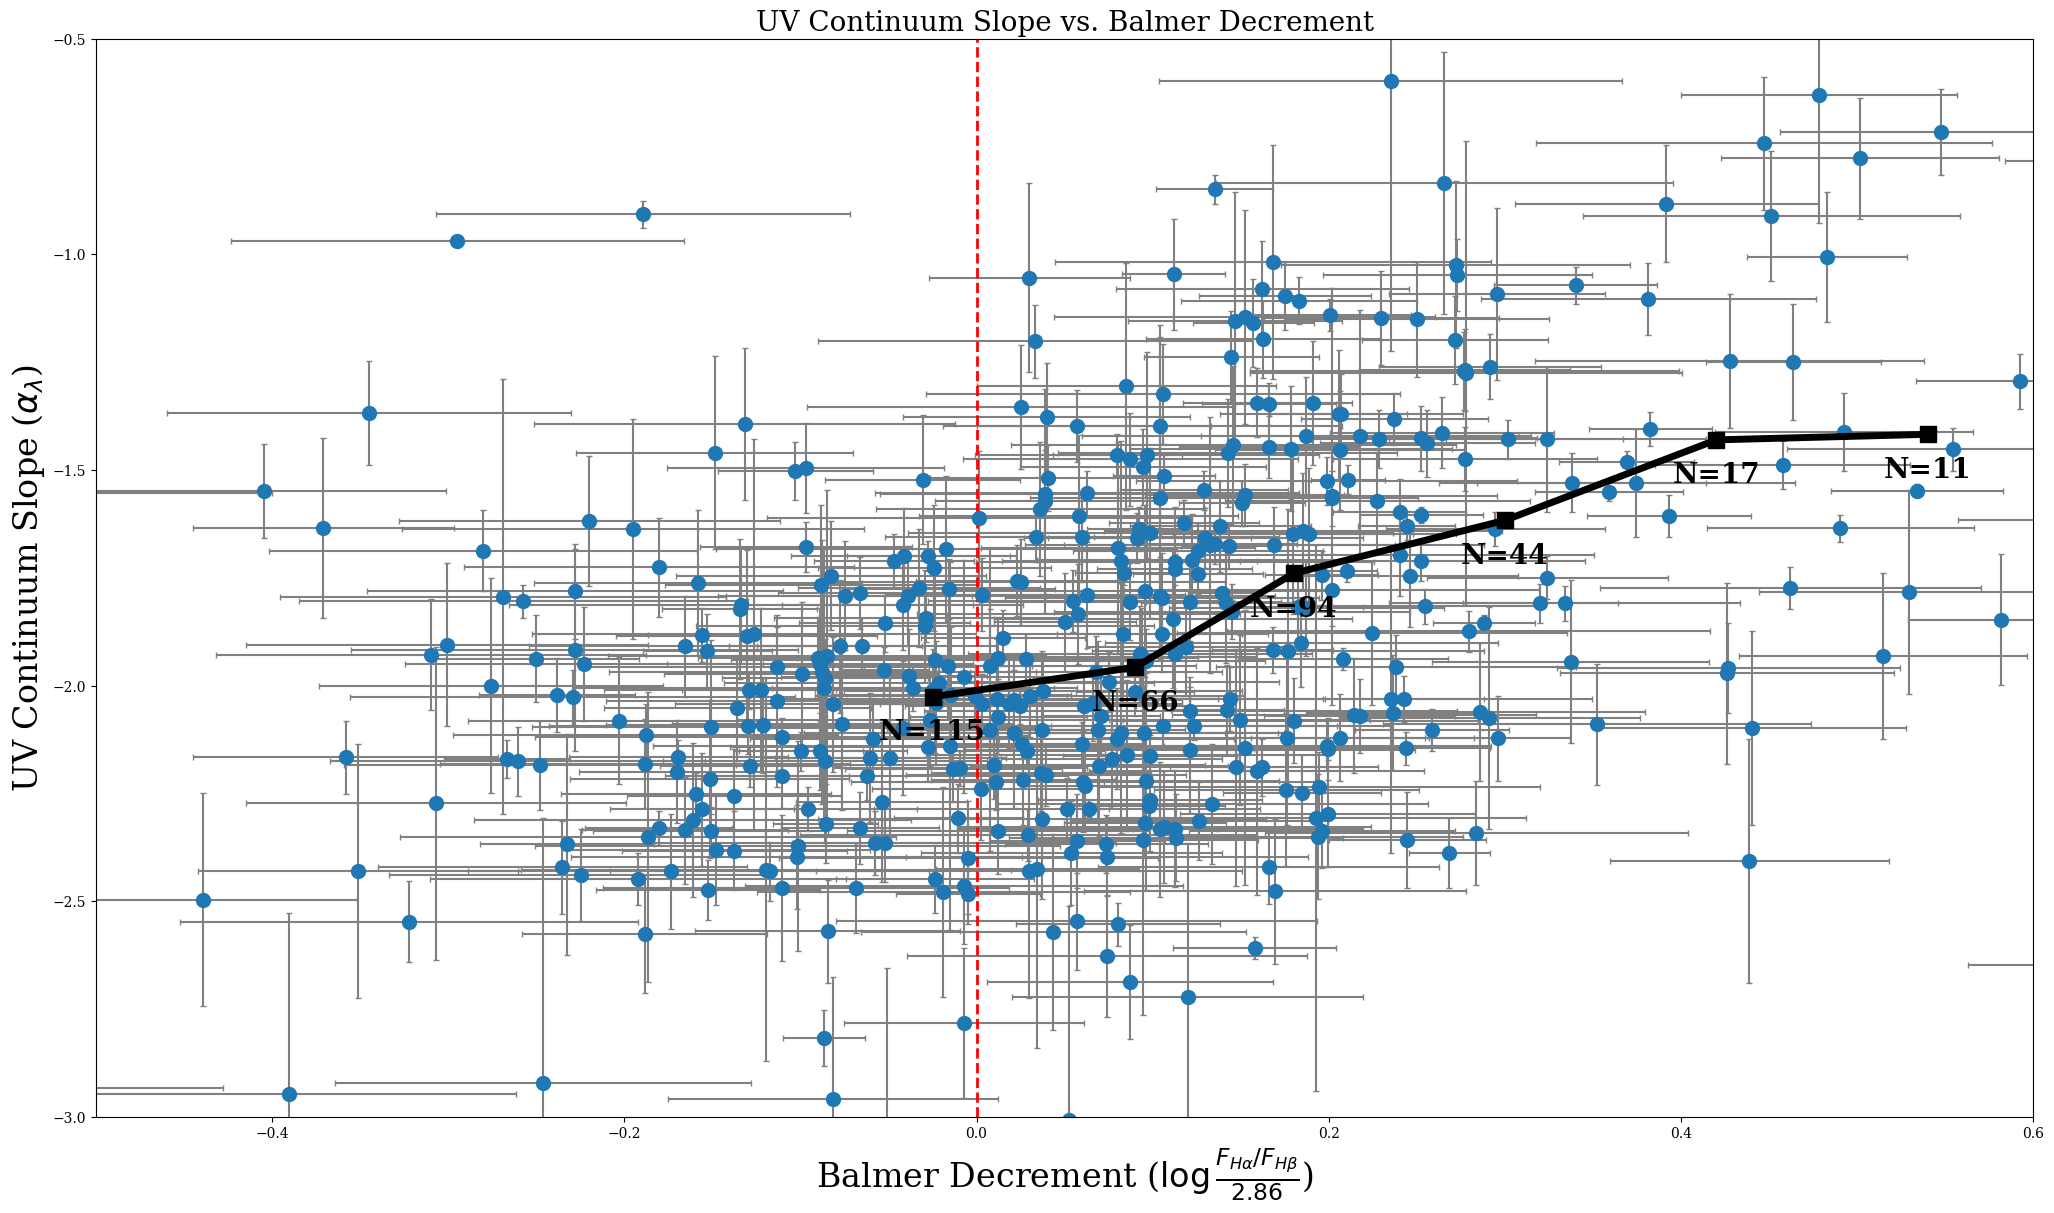

In [13]:

fig, ax = plt.subplots(figsize=(25,14))
ax.errorbar(balmer_decrement_array, uv_slope_array,
            xerr=balmer_decrement_uncertainty_array,
            yerr=uv_slope_err_array,
            fmt='o', ecolor='gray', capsize=2, markersize=10, label='Data Points')
ax.set_xlabel(r'Balmer Decrement ($\log \frac{F_{H\alpha}/F_{H\beta}}{2.86}$)', fontsize=24)
ax.set_ylabel(r'UV Continuum Slope ($\alpha_\lambda$)', fontsize=24)
ax.set_title('UV Continuum Slope vs. Balmer Decrement', fontsize=20)
ax.axvline(x=0, color='red', linestyle='--', lw=2, label='Case B Recombination (2.86)')
ax.set_xlim(-0.5,0.6)
ax.set_ylim(-3,-0.5)

group_conditions = [(-0.1,0.05),(0.06,0.12), (0.12,0.24),(0.24,0.36),(0.36,0.48),(0.48,0.6)]
last_point_x=None
last_point_y=None

for lower, upper in group_conditions:
    group_mask = (balmer_decrement_array >= lower) & (balmer_decrement_array < upper)
    group_num=np.sum(group_mask)
    if group_num == 0:
        continue
    group_uv_slopes = uv_slope_array[group_mask]
    group_uv_slope_errs = uv_slope_err_array[group_mask]

    lower_value=5
    upper_value=100-lower_value


    mask_lower_16_upper_84 = (group_uv_slopes >= percentile(group_uv_slopes,lower_value)) & (group_uv_slopes <= percentile(group_uv_slopes, upper_value))
    group_uv_slopes = group_uv_slopes[mask_lower_16_upper_84]


    weighted_mean_uv_slope = np.average(group_uv_slopes)

    mid_point = (lower + upper) / 2
    z=30

    ax.scatter(mid_point, weighted_mean_uv_slope,
                marker='s', color='black', s=144,
                label=f'Bin [{lower:.2f}, {upper:.2f}] Mean' if lower == group_conditions[0][0] else "", zorder=z)

    if last_point_x is not None and last_point_y is not None:
        ax.plot([last_point_x, mid_point], [last_point_y, weighted_mean_uv_slope], color='black', linewidth=5, zorder=z)
    last_point_x = mid_point
    last_point_y = weighted_mean_uv_slope

    plt.text(mid_point, weighted_mean_uv_slope-0.1, f'N={group_num}', fontsize=20, ha='center',zorder=z,c='black',fontweight='bold')

Text(0, 0.5, 'Density')

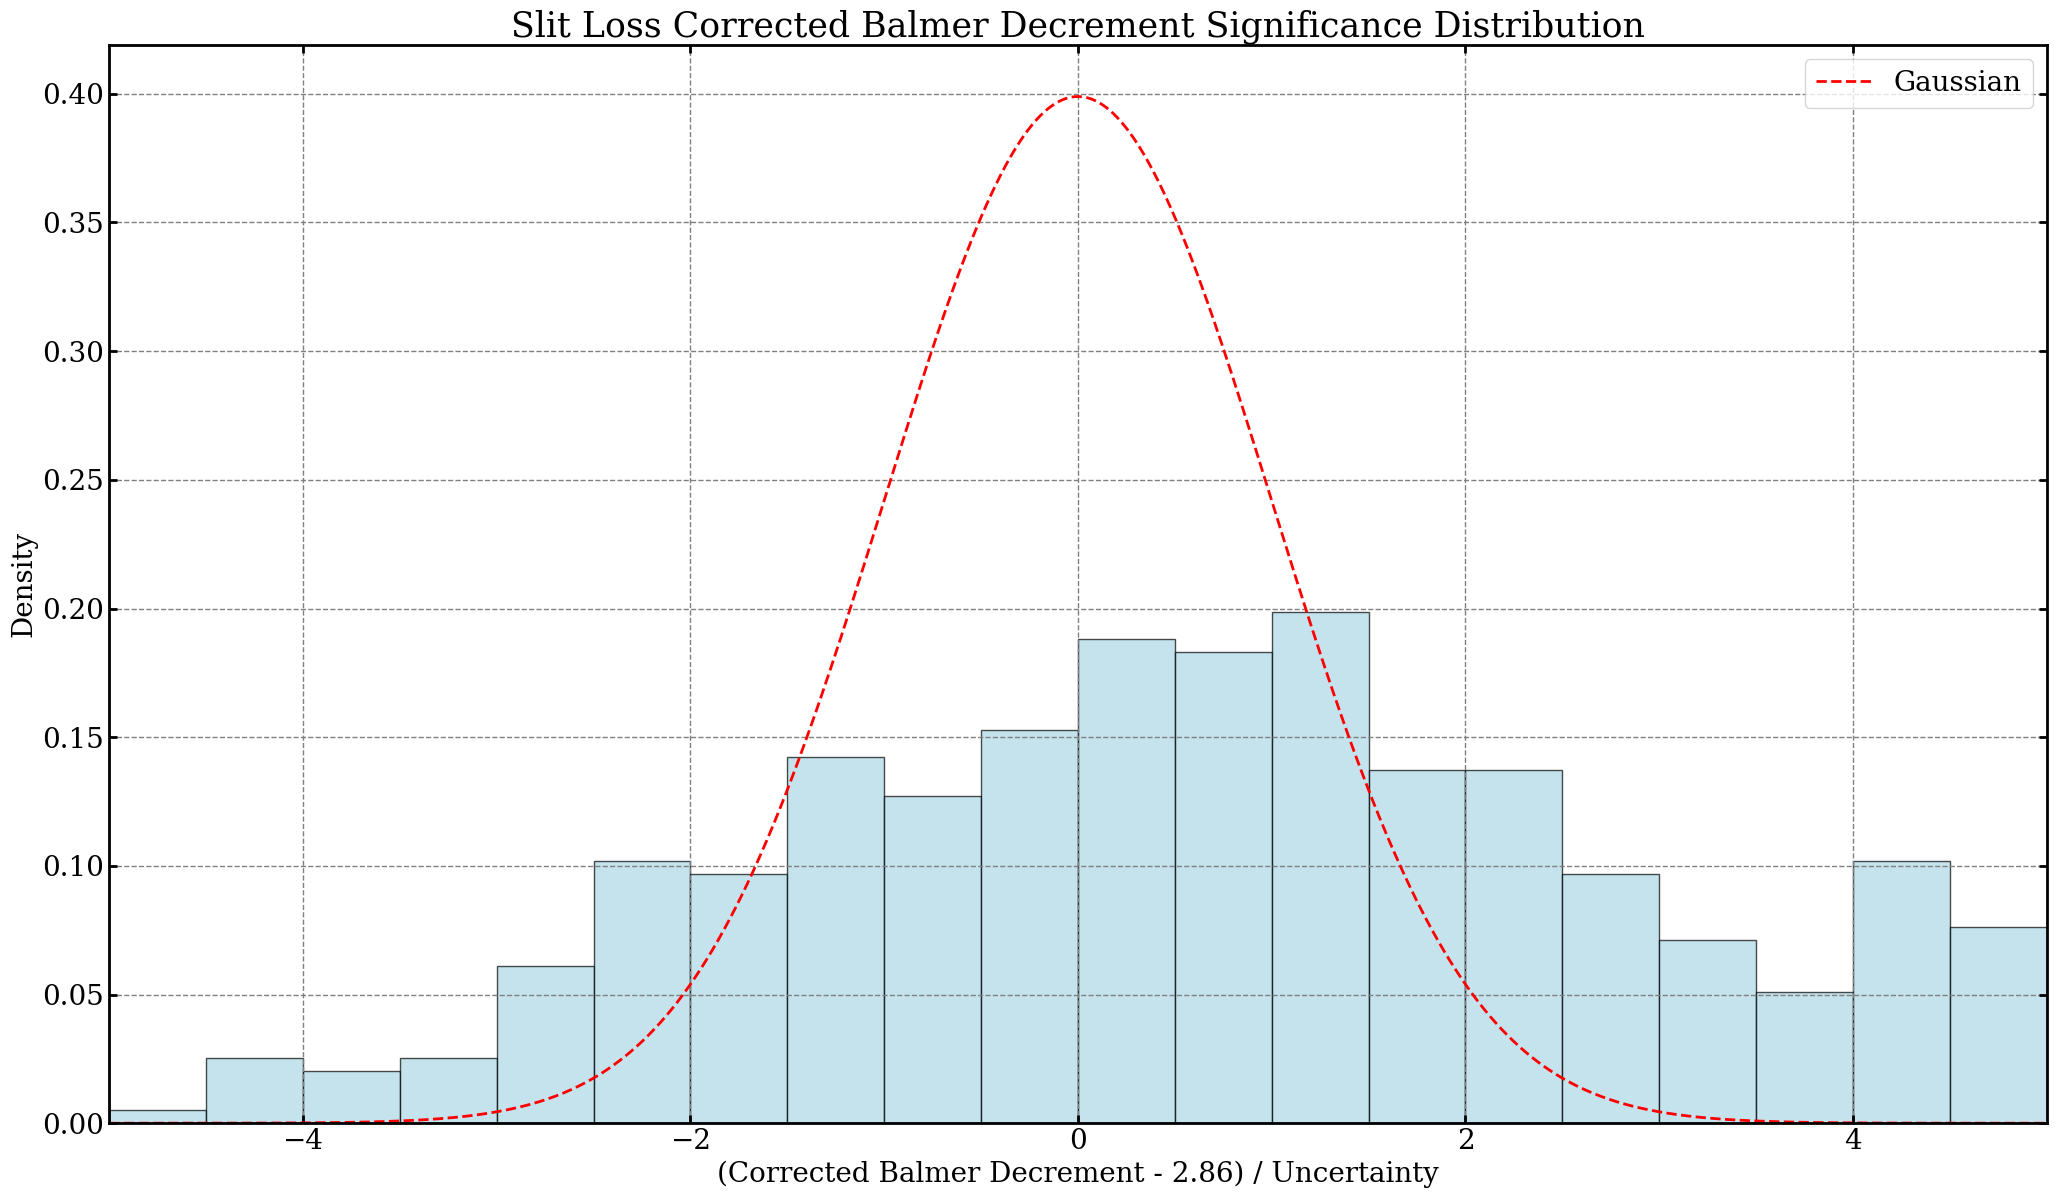

In [19]:

fig, ax = plt.subplots(figsize=(25,14))
ax.hist(balmer_decrement_array/balmer_decrement_uncertainty_array, bins=20, density=True, color='lightblue', edgecolor='black', alpha=0.7,range=(-5,5))

from scipy.stats import norm
import numpy as np
mean=0
std_dev=1
x = np.linspace(-5, 5, 1000)
y = norm.pdf(x, mean, std_dev)
#scale y to match the histogram

ax.plot(x,y, color='r', linestyle='--', linewidth=2, label='Gaussian')
ax.set_xlim(-5, 5)

ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=20)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=1)
ax.grid(visible=True, which='minor', color='lightgray', linestyle='--', linewidth=0.5)
ax.legend(fontsize=20, loc='best')
ax.set_title('Slit Loss Corrected Balmer Decrement Significance Distribution', fontsize=25)
ax.set_xlabel('(Corrected Balmer Decrement - 2.86) / Uncertainty', fontsize=20)
ax.set_ylabel('Density', fontsize=20)

In [20]:
balmer_decrement_uncertainty_array.shape

(458,)